
 # Mental Health Detection NLP Project

# **CMSC320 Final Tutorial Notebook**
#
# **Team Members & Contributions:**
# - **Siraj Khan:** Data Curation, Schema Remapping, Hypothesis Testing, Ethics & Conclusions
# - **Vashawn Robinson:** Text Preprocessing, EDA Part 1 (Text Patterns), Notebook Assembly & GitHub Pages Deployment
# - **Armin Ahmadkhaniha:** Feature Engineering, EDA Part 2 (Numeric Features), Random Forest, Model Comparison Visualizations
# - **Fatima Mobdij:** NLP Pipeline Setup (TF-IDF & Keras Tokenization), Logistic Regression Baseline, LinearSVC, Dense Neural Network


# Summary
Social media has become part of day to day life of society. People share their thoughts, ideas and feelings in the virtual world, but can they also share symptoms of mental health issues without even knowing it? In this project our main goal is to find a way to detect signs of mental health issues using social media data and people's writing patterns.

Mental health affects 1 in 8 people worldwide, yet many cases go undetected until it is too late. Early detection tools are still hard to access and expensive. This is where data science can make a real difference. By using data people already write publicly, we can build low-cost, scalable tools that flag potential mental health concerns early.

We use Natural Language Processing (NLP) and Machine Learning to classify Reddit posts across multiple mental health conditions, including Depression, Anxiety, Bipolar Disorder, ADHD, and PTSD. Our dataset combines two sources: the Murarka et al. (2021) Reddit Mental Health Dataset, published at ACL 2021, and the Sarkar Kaggle Dataset, giving us over 60,000 labeled samples to work with.

This project is a hands-on tutorial that walks users through the full data science pipeline - from data collection and preprocessing, to exploratory data analysis, hypothesis testing, machine learning model comparison, and neural networks - with clear explanations and visualizations, and a focus on NLP and responsible, ethical AI.


## PART I : DATA Curation
We Use **Murarka et al. (2021) dataset** on specifying mental health issues among teenagers by using their posts to train our model there will be few datasets that have None identification we use them as final test of our model to see how it specify them
To establish an accurate diagnostic boundary, we map baseline posts ( `Normal` from Combined Data-2) into a unified **`Normal`** class. This teaches our models what "okay" mental health language looks like.
We then separate our dataset into two distinct branches:
1- **Main 6-Class Dataset (`mental_health_6_classes_cleaned.csv`):** Contains our 5 clinical conditions + Normal baseline (used for EDA, TF-IDF, and model training).
2- **Out-of-Scope Holdout Set (`mental_health_out_of_scope_holdout.csv`):** Preserves `Suicidal`, `Stress`, and `Personality disorder` posts separately to run our final Checkpoint 3 experiment comparing AI predictions against human observations.



In [16]:

import re
import pandas as pd
import numpy as np

## Load Datasets
df_train = pd.read_csv('both_train.csv')
df_val = pd.read_csv('both_val.csv')
df_test = pd.read_csv('both_test.csv')
df_ds1 = pd.concat([df_train, df_val, df_test], ignore_index=True)

df_ds1['text'] = df_ds1['title'].fillna('') + " " + df_ds1['post'].fillna('')
df_ds1['raw_label'] = df_ds1['class_name']
df_ds1['source'] = 'Dataset_1_Reddit'
df_ds1_clean = df_ds1[['text', 'raw_label', 'source']]

df_ds2 = pd.read_csv('Combined Data-2.csv')
df_ds2['text'] = df_ds2['statement']
df_ds2['raw_label'] = df_ds2['status']
df_ds2['source'] = 'Dataset_2_Combined'
df_ds2_clean = df_ds2[['text', 'raw_label', 'source']]

## concatenate
df_raw = pd.concat([df_ds1_clean, df_ds2_clean], ignore_index=True)
initial_count = len(df_raw)
print(f"Total raw rows loaded: {initial_count:,}")

# Drop null texts or null labels
df_clean = df_raw.dropna(subset=['text', 'raw_label']).copy()
after_nulls = len(df_clean)
print(f"Dropped {initial_count - after_nulls:,} missing/null rows -> Remaining: {after_nulls:,}")
# Remove duplicates
df_clean = df_clean.drop_duplicates(subset=['text']).reset_index(drop=True)
after_dupes = len(df_clean)
print(f"Dropped {after_nulls - after_dupes:,} duplicate rows -> Remaining: {after_dupes:,}")

## remapping
def clean_raw_artifacts(text):
    text = str(text)
    text = re.sub(r'&amp;#x200b;|&amp;|&gt;|&lt;|&#x200b;', ' ', text) ## Decode HTML entities
    text = re.sub(r'\[removed\]|\[deleted\]', '', text, flags=re.IGNORECASE) ## Remove Reddit tags
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['text'] = df_clean['text'].apply(clean_raw_artifacts)

##  Define our 6-Class Training Schema vs Out-of-Scope Holdout Schema
schema_mapping = {
    'adhd': 'ADHD',
    'depression': 'Depression',
    'anxiety': 'Anxiety',
    'bipolar': 'Bipolar',
    'ptsd': 'PTSD',
    'none': 'Holdout_Reddit_None', ##preserved for testing
    'Normal': 'Normal',            ##base
    'Depression': 'Depression',
    'Anxiety': 'Anxiety',
    'Bipolar': 'Bipolar',
    'Suicidal': 'Holdout_Suicidal',                         ##preserved for testing
    'Personality disorder': 'Holdout_Personality_Disorder', ##preserved for testing
    'Stress': 'Holdout_Stress'                              ##preserved for testing
}

df_clean['mapped_label'] = df_clean['raw_label'].map(schema_mapping)
df_clean = df_clean.dropna(subset=['mapped_label']).reset_index(drop=True)

## Word count
df_clean['word_count'] = df_clean['text'].apply(lambda x: len(x.split()))
p99_threshold = df_clean['word_count'].quantile(0.99)

df_final = df_clean[(df_clean['word_count'] >= 5) & (df_clean['word_count'] <= p99_threshold)].copy()
df_final = df_final.reset_index(drop=True)

print(f"Filtered posts under 5 words and above 99th percentile ({p99_threshold:.0f} words).")
print(f"Total clean rows ready for branching: {len(df_final):,}")


##Main 6-Class Training & EDA Dataset with base line
df_main = df_final[~df_final['mapped_label'].str.startswith('Holdout_')].copy()
df_main.rename(columns={'mapped_label': 'label'}, inplace=True)
file_train_eda = 'mental_health_6_classes_cleaned.csv'
df_main[['text', 'label', 'source', 'word_count']].to_csv(file_train_eda, index=False)

## Out-of-Scope Holdout Dataset (For Human vs. Model Experiment)
df_holdout = df_final[df_final['mapped_label'].str.startswith('Holdout_')].copy()
df_holdout['holdout_category'] = df_holdout['mapped_label'].str.replace('Holdout_', '').str.replace('_', ' ')
file_holdout = 'mental_health_out_of_scope_holdout.csv'
df_holdout[['text', 'raw_label', 'holdout_category', 'source', 'word_count']].to_csv(file_holdout, index=False)

print(f"Training/EDA : '{file_train_eda}' ({len(df_main):,} rows)")
print("   -> Class Distribution:")
print(df_main['label'].value_counts().to_string())

print(f"\nExperiments : '{file_holdout}' ({len(df_holdout):,} rows)")
print("   -> Class Distrubution")
print(df_holdout['raw_label'].value_counts().to_string())

Total raw rows loaded: 69,746
Dropped 362 missing/null rows -> Remaining: 69,384
Dropped 1,614 duplicate rows -> Remaining: 67,770
Filtered posts under 5 words and above 99th percentile (872 words).
Total clean rows ready for branching: 64,307
Training/EDA : 'mental_health_6_classes_cleaned.csv' (48,271 rows)
   -> Class Distribution:
label
Depression    17769
Normal        13450
Anxiety        6390
Bipolar        5338
ADHD           2899
PTSD           2425

Experiments : 'mental_health_out_of_scope_holdout.csv' (16,036 rows)
   -> Class Distrubution
raw_label
Suicidal                10503
none                     2359
Stress                   2285
Personality disorder      889


## PART II: Text Preprocessing & Feature Engineering
The Goal for this part is to make our data set ready for trainning models and use them teh evalute our final tests.We take the raw text from mental_health_6_classes_cleaned.csv and transforms it into clean tokens for machine learning, while other teammate builds numeric features (lengths, punctuation density, and VADER sentiment scores) that feed into your Exploratory Data Analysis (EDA) and hypothesis testing.

In [17]:

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
!pip install vaderSentiment ## adding package in google collab
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## required Nltk data for proccessing
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

df_main = pd.read_csv('mental_health_6_classes_cleaned.csv')
print(f"dataset shape: {df_main.shape[0]:,} rows, {df_main.shape[1]} columns")

## Text porcessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    ## Lowercase all text
    text = str(text).lower()
    ## Remove URLs using regex
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    ## Remove HTML tags and residual markup
    text = re.sub(r'<.*?>|\[removed\]|\[deleted\]', '', text)
    ## Remove punctuation and special characters
    text = re.sub(r"[^\w\d\s']", '', text)
    ## Tokenization using nltk.word_tokenize
    tokens = word_tokenize(text)
    ## Stopword removal
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1] ##iterate through each text
    ## join
    return " ".join(tokens)

df_main['clean_text'] = df_main['text'].apply(preprocess_text)

## drop rows which rturn empty after proccessing
initial_rows = len(df_main)
df_main = df_main[df_main['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f"Dropped {initial_rows - len(df_main)} empty rows after cleaning -> Valid rows remaining: {len(df_main):,}")

## Feature engineering
analyzer = SentimentIntensityAnalyzer()

## Post length based on word
df_main['word_count'] = df_main['clean_text'].apply(lambda x: len(x.split()))

## Punctuation density in each post
def get_punct_density(text):
    text_str = str(text)
    punct_count = sum(text_str.count(p) for p in ('!', '?'))
    raw_words = max(len(text_str.split()), 1)
    return punct_count / raw_words

df_main['punct_density'] = df_main['text'].apply(get_punct_density)

## Sentiment score: VADER compound score per post
df_main['sentiment_score'] = df_main['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

preview_cols = ['label', 'clean_text', 'word_count', 'punct_density', 'sentiment_score']
print(df_main[preview_cols].head().to_string())

## Save all engineered features and cleaned text
output_file = 'mental_health_preprocessed.csv'
df_main.to_csv(output_file, index=False)


dataset shape: 48,271 rows, 4 columns
Dropped 20 empty rows after cleaning -> Valid rows remaining: 48,251
        label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      clean_text  word_count  punct_density  sentiment_score
0        ADHD                                                      

## PART III : TEXT PATTERN IDENTIFICATION
In this part we are trying to identify patterns that highlight the structural vocabulary and distribution of our 6-class dataset (`mental_health_preprocessed.csv`). We examine class imbalances, identify high-frequency terms unique to each mental health condition, and visualize semantic patterns using word clouds.

/tmp/ipykernel_1474/2203746252.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_eda, x='label', order=class_order, palette='viridis')


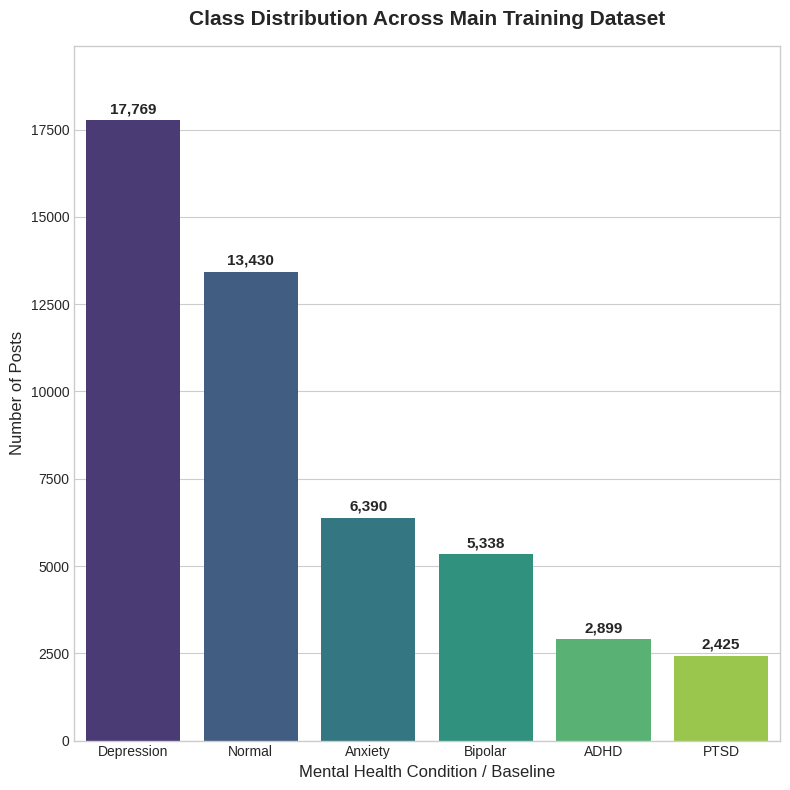

/tmp/ipykernel_1474/2203746252.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq.values, y=word_freq.index, ax=axes[i], palette='magma')
/tmp/ipykernel_1474/2203746252.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq.values, y=word_freq.index, ax=axes[i], palette='magma')
/tmp/ipykernel_1474/2203746252.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq.values, y=word_freq.index, ax=axes[i], palette='magma')
/tmp/ipykernel_1474/2203746252.py:39: FutureWarning: 

Passing `palette` without assigning 

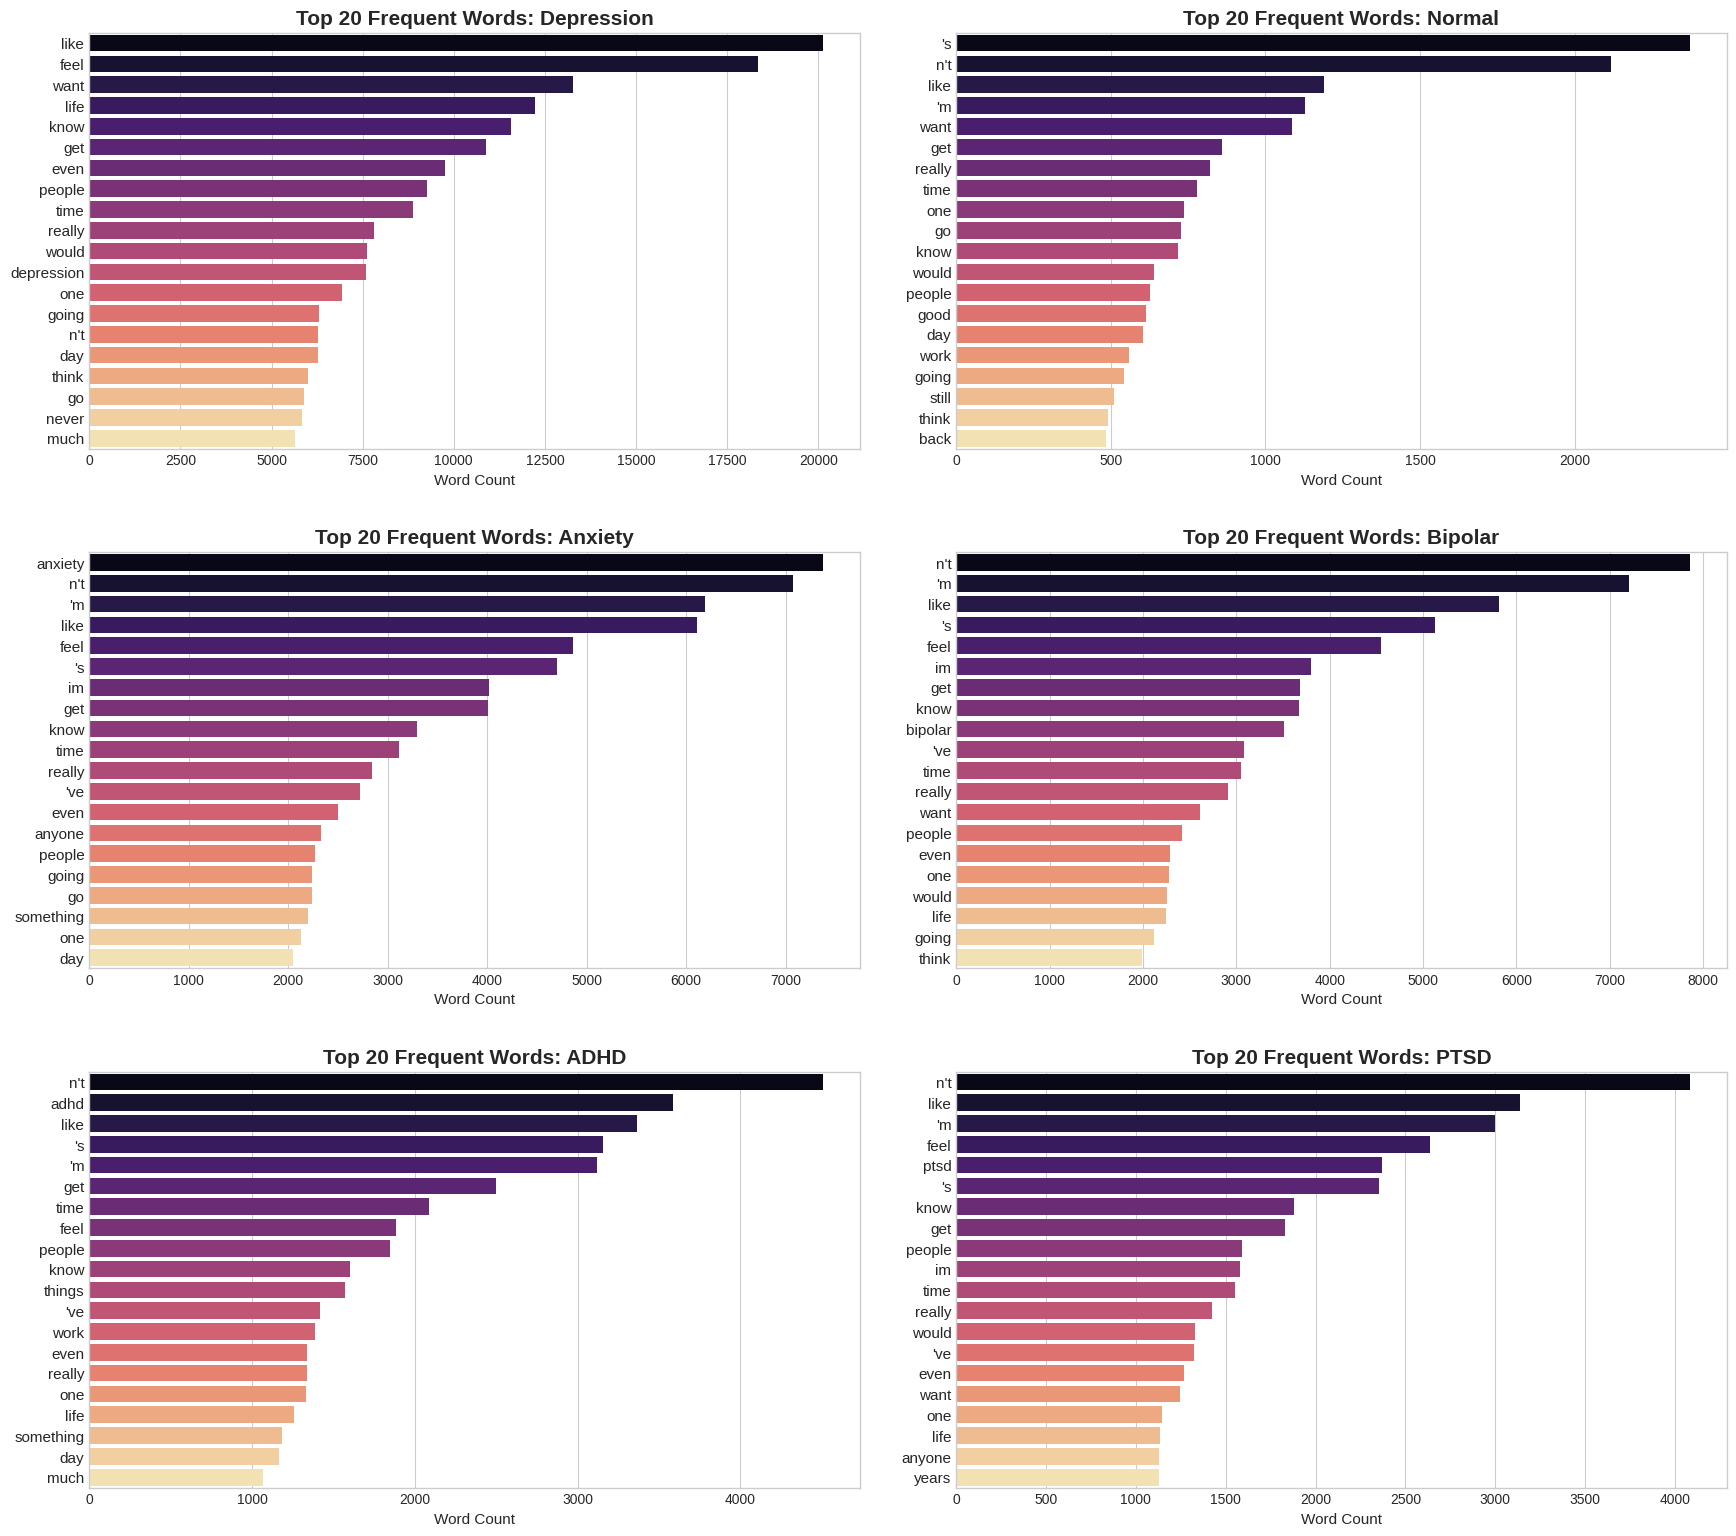

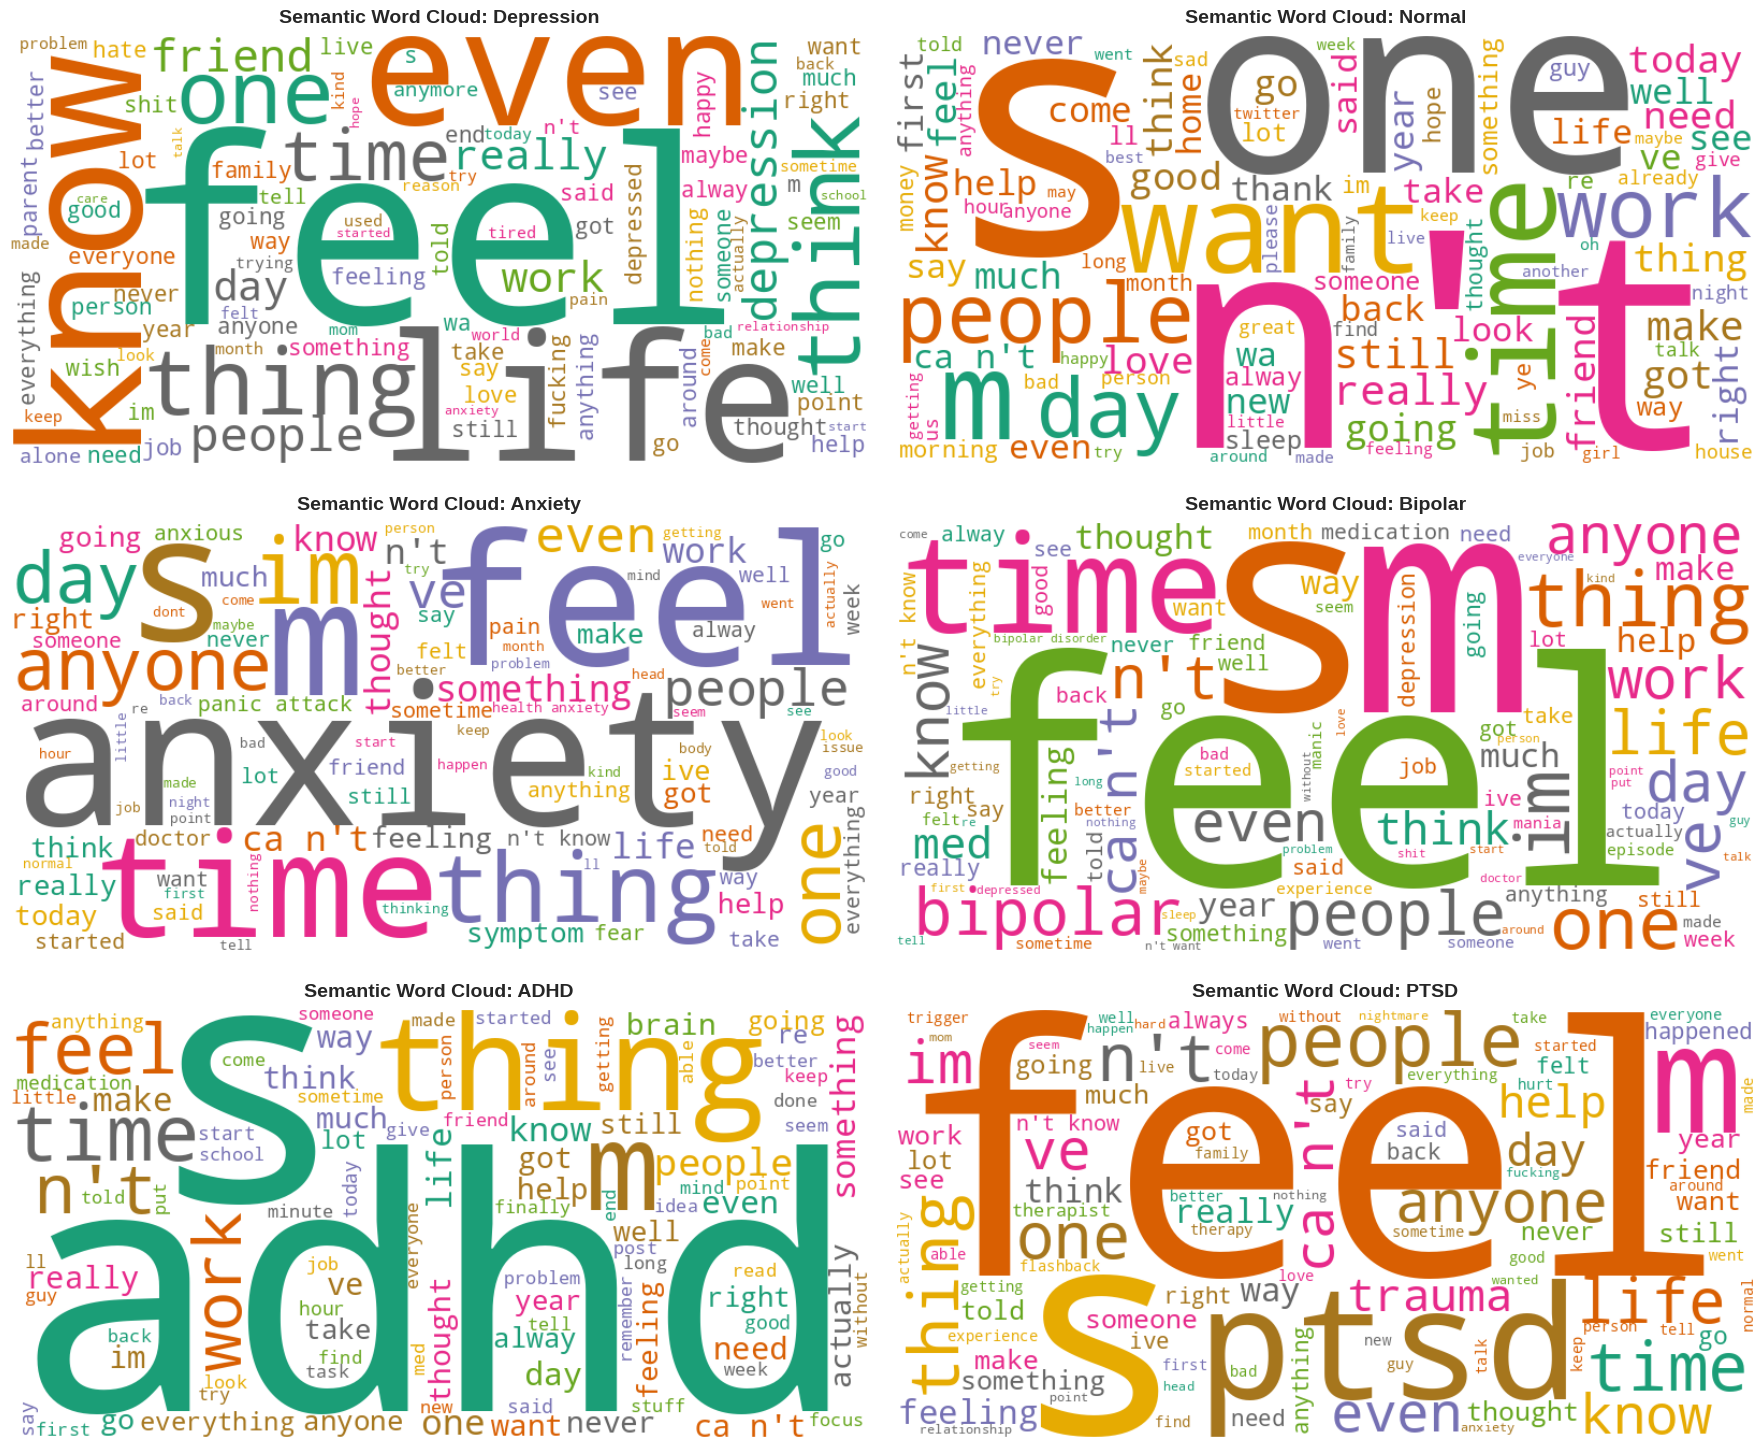

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

df_eda = pd.read_csv('mental_health_preprocessed.csv')

## Get unique classes sorted by frequency
class_order = df_eda['label'].value_counts().index.tolist()
colors = sns.color_palette('viridis', len(class_order))

## Plotting Bar chart for each class
plt.figure(figsize=(8, 8))
ax = sns.countplot(data=df_eda, x='label', order=class_order, palette='viridis')

plt.title('Class Distribution Across Main Training Dataset', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Mental Health Condition / Baseline', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8),
                textcoords='offset points', fontweight='bold', fontsize=11)

plt.ylim(0, df_eda['label'].value_counts().max() * 1.12)
plt.tight_layout()
plt.show()
## Identify WORD frequency in each class
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, cls in enumerate(class_order):
    cls_text = " ".join(df_eda[df_eda['label'] == cls]['clean_text'].dropna())
    word_freq = pd.Series(cls_text.split()).value_counts().head(20) ## top 20 freqency of words
## Plotting a bar chart
    sns.barplot(x=word_freq.values, y=word_freq.index, ax=axes[i], palette='magma')
    axes[i].set_title(f'Top 20 Frequent Words: {cls}', fontsize=15, fontweight='bold')
    axes[i].set_xlabel('Word Count', fontsize=11)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='y', labelsize=11)
plt.tight_layout(pad=3.0)
plt.show()

## Word Clouds per class
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()
for i, cls in enumerate(class_order):
    cls_text = " ".join(df_eda[df_eda['label'] == cls]['clean_text'].dropna())
## Generate Word Cloud
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='Dark2', max_words=100, contour_width=1, contour_color='steelblue').generate(cls_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Semantic Word Cloud: {cls}', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout(pad=2.0)
plt.show()



## Interpertation
Our Data is Imbalanced and mostly filled with patients who are suffering mostly from **Depression and Anxiety**. because of this model will probably biased toward Normal and Deprresion and might struggel to identify other classes. since this is the case we suppose to give weight to each class so minorites also be added to model trainning and help model be able to identify them as well.
Additionally, The heavy presence of "feel", "want", and first-person pronouns ("'m", "im") across the board indicates deeply personal, reflective, and emotionally driven writing which is a good strating point to train our model what to look for mostly. also some of the patients have used their diagnosis in their posts such as **Depression,Anxiety and Bipolar**. final note about the results is that while teenagers across all mental health spectrums use similar emotional and first-person framing ("feel", "want", "im"), their specific struggles are linguistically distinct.
**Depression is existential**
**Anxiety is situational/social**
**Bipolar is clinical/cyclical**
**ADHD is task- and focus-oriented**
and
**PTSD is memory- and trauma-oriented**


## PART IV: Statistal Hypothesis Testing
While last part visually suggests that text lengths and sentiment scores differ across mental health conditions, science wiith few common areas ,it requires mathematical proof. In this section, we run three formal statistical tests to prove that our engineered features (word_count and sentiment_score) contain statistically significant predictive power for machine learning. We will use :
**MANN WHITHNEY U TEST**
**CHI-SQUARED CONTINGENCY** and
**Kruskal Wallis TEST**

Loaded dataset for Hypothesis Testing: 48,251 rows
Depression Median Word Count: 50.0
Normal Baseline Median Word Count: 7.0
Mann-Whitney U Statistic: 221,449,744.0000
p-value: 0.0000e+00


/tmp/ipykernel_1474/3845354565.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats[df_stats['label'].isin(['Depression', 'Normal'])],


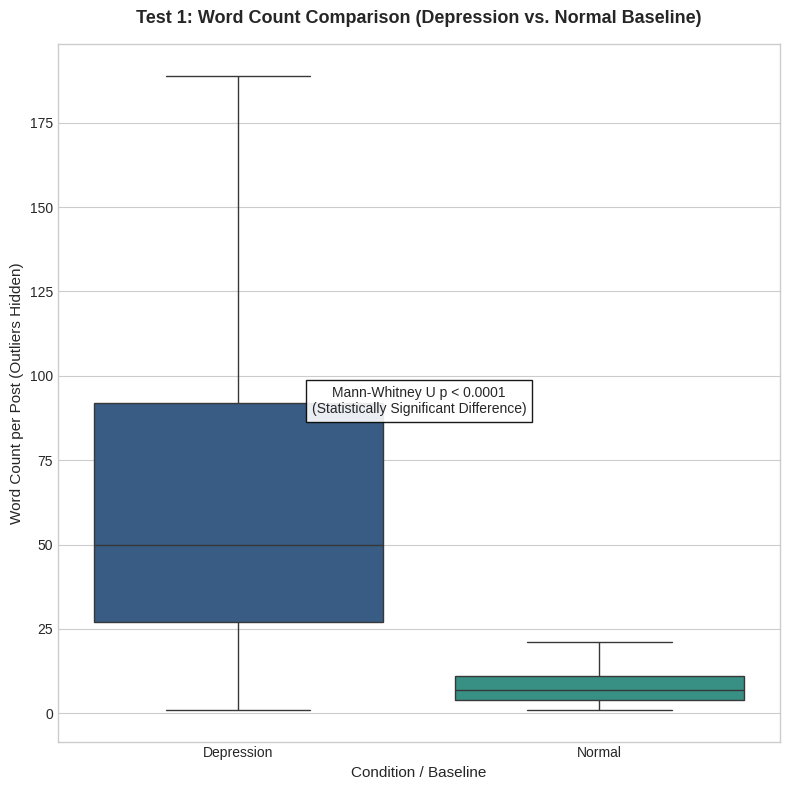

Contingency Table (Observed Counts):
sentiment_category  High Sentiment (>=0.0)  Low Sentiment (<0.0)
label                                                           
ADHD                                  1756                  1143
Anxiety                               2246                  4144
Bipolar                               2543                  2795
Depression                            5870                 11899
Normal                                9690                  3740
PTSD                                   792                  1633

Chi-Squared Statistic: 5,567.9680
Degrees of Freedom: 5
p-value: 0.0000e+00


<Figure size 800x800 with 0 Axes>

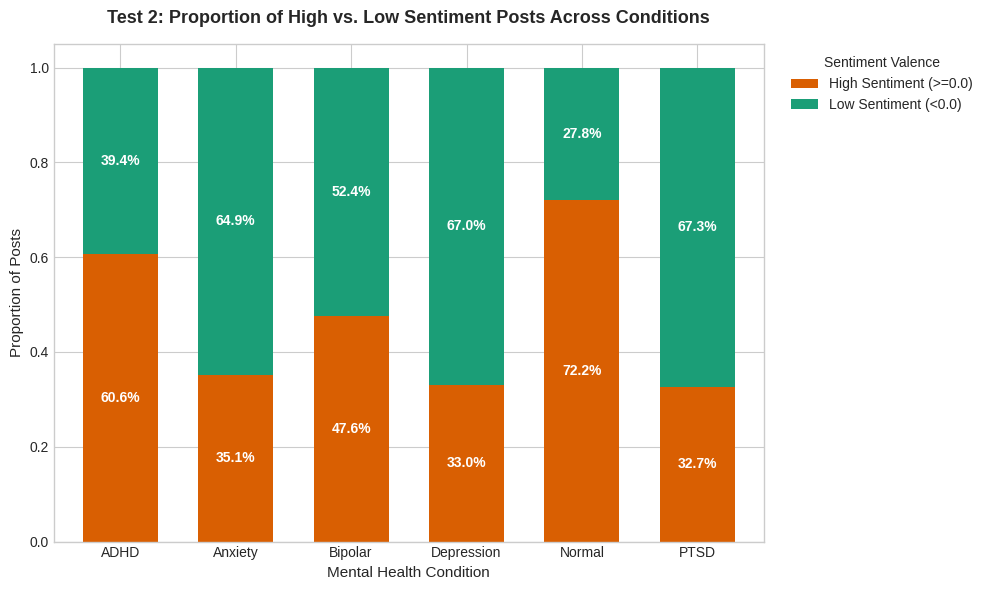

Kruskal-Wallis Statistic: 4,009.9916
p-value: 0.0000e+00


/tmp/ipykernel_1474/3845354565.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_stats, x='label', y='sentiment_score', palette='Spectral', inner='quartile', cut=0)


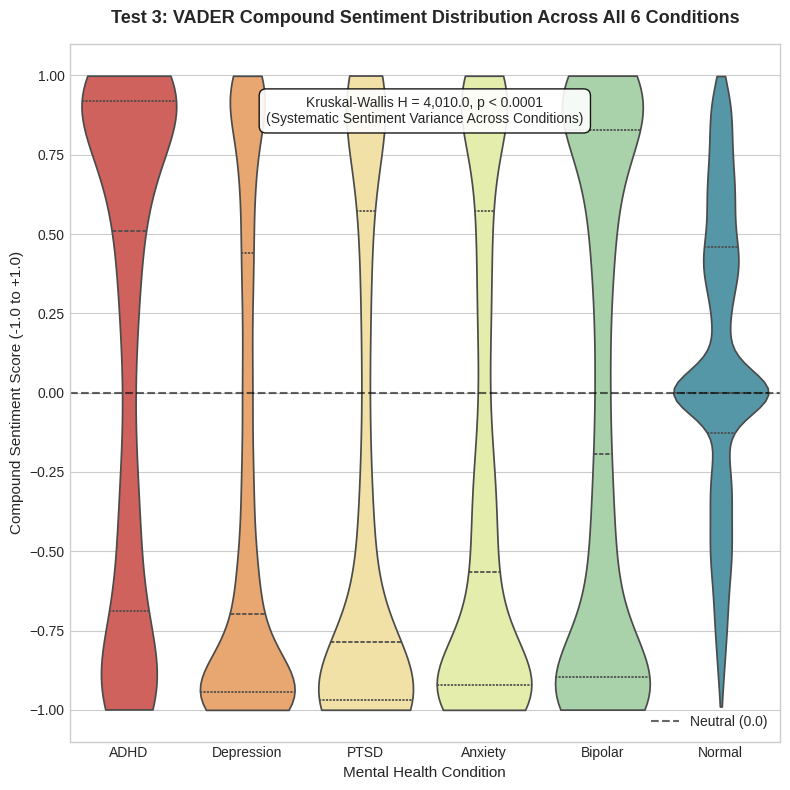

In [19]:

from scipy import stats

## Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

df_stats = pd.read_csv('mental_health_preprocessed.csv')
print(f"Loaded dataset for Hypothesis Testing: {df_stats.shape[0]:,} rows")

## Extract word counts for Depression and Normal classes
dep_words = df_stats[df_stats['label'] == 'Depression']['word_count'].dropna()
norm_words = df_stats[df_stats['label'] == 'Normal']['word_count'].dropna()

## Run two-sided Mann-Whitney U test
stat_mwu, p_mwu = stats.mannwhitneyu(dep_words, norm_words, alternative='two-sided')

print(f"Depression Median Word Count: {dep_words.median():.1f}")
print(f"Normal Baseline Median Word Count: {norm_words.median():.1f}")
print(f"Mann-Whitney U Statistic: {stat_mwu:,.4f}")
print(f"p-value: {p_mwu:.4e}")

## Boxplot
plt.figure(figsize=(8, 8))
sns.boxplot(data=df_stats[df_stats['label'].isin(['Depression', 'Normal'])],
            x='label', y='word_count', palette=['#2b5c8f', '#2a9d8f'], showfliers=False)

plt.title('Test 1: Word Count Comparison (Depression vs. Normal Baseline)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Condition / Baseline', fontsize=11)
plt.ylabel('Word Count per Post (Outliers Hidden)', fontsize=11)

## P-value
plt.text(0.5, df_stats[df_stats['label'].isin(['Depression', 'Normal'])]['word_count'].quantile(0.85),
         f"Mann-Whitney U p < 0.0001\n(Statistically Significant Difference)",
         horizontalalignment='center', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))
## plot
plt.tight_layout()
plt.show()

## Create binary sentiment category (High >= 0.0, Low < 0.0)
df_stats['sentiment_category'] = np.where(df_stats['sentiment_score'] >= 0.0, 'High Sentiment (>=0.0)', 'Low Sentiment (<0.0)')
contingency_table = pd.crosstab(df_stats['label'], df_stats['sentiment_category'])
print("Contingency Table (Observed Counts):")
print(contingency_table)

## Run Chi-Squared test
stat_chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Squared Statistic: {stat_chi2:,.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value: {p_chi2:.4e}")

contingency_prop = contingency_table.div(contingency_table.sum(1), axis=0)
## plot
plt.figure(figsize=(8, 8))
ax = contingency_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#d95f02', '#1b9e77'], width=0.65)

plt.title('Test 2: Proportion of High vs. Low Sentiment Posts Across Conditions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mental Health Condition', fontsize=11)
plt.ylabel('Proportion of Posts', fontsize=11)
plt.legend(title='Sentiment Valence', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

## Add percentage
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0.05: ## Only label if bar is tall enough
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height*100:.1f}%',
                horizontalalignment='center', verticalalignment='center',
                color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Group sentiment scores by class
kw_groups = [group['sentiment_score'].values for name, group in df_stats.groupby('label')]

## Run Kruskal-Wallis
stat_kw, p_kw = stats.kruskal(*kw_groups)

print(f"Kruskal-Wallis Statistic: {stat_kw:,.4f}")
print(f"p-value: {p_kw:.4e}")

## Plot Violin
plt.figure(figsize=(8, 8))
sns.violinplot(data=df_stats, x='label', y='sentiment_score', palette='Spectral', inner='quartile', cut=0)

plt.title('Test 3: VADER Compound Sentiment Distribution Across All 6 Conditions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mental Health Condition', fontsize=11)
plt.ylabel('Compound Sentiment Score (-1.0 to +1.0)', fontsize=11)
plt.axhline(0, color='black', linestyle='--', alpha=0.6, label='Neutral (0.0)')

plt.text(2.5, 0.85, f"Kruskal-Wallis H = {stat_kw:,.1f}, p < 0.0001\n(Systematic Sentiment Variance Across Conditions)",
         horizontalalignment='center', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



## TESTS INTERPERTATION
at First with using **MANN WHITHNEY U TEST** we try to compare patients who suffering from depression with our base line which is normal people. We found that :
Teenagers experiencing depression write vastly longer posts—over 7 times longer on average—than the normal baseline.
This indicates a behavioral difference in how online spaces are used. "Normal" interactions are brief, casual, or transactional (median of 7 words is often just a sentence or a quick reply). Depression posts require massive emotional unpacking, storytelling, and venting which explain median of 50 words. this is stronge que for our model to trainned on


With **CHI SQUARED TEST** Test we check if the categorical distribution of "High" (≥0.0) vs. "Low" (<0.0) sentiment is independent of the condition. The result (p<0.0001) shows they are heavily dependent.
The "Distress" Trio (**Depression,PTSD and Anxiety**): These three show nearly identical distributions, with 65% to 67% of their posts falling into low sentiment. This statistically groups them as conditions defined by acute emotional pain.
The **Bipolar** posts are split almost perfectly down the middle (52.4% Low vs. 47.6% High). This finding explain perfectly mirrors the clinical diagnostic reality of Bipolar disorder—oscillating between depressive (low sentiment) and manic/hypomanic (high sentiment) states.
The **ADHD**
 Outlier: ADHD breaks the mold of the other conditions with 60.6% High Sentiment. This supports word cloud finding: teenagers with ADHD aren't necessarily using online spaces to express pure emotional sadness, but rather to discuss focus, tasks, school, and strategies, which VADER scores as more neutral or positive.
Normal Baseline: As expected, it serves as a healthy control group, with 72.2% High Sentiment.

The **KRUSKAL WALLIS TEST** proves the Violin shapes are systematically different (p<0.0001).
The Plotts for negative distresses like **Depression,Anxiety and PTSD** shows that when these posts are negative, they aren't just slightly sad; they are severely distressed, pooling heavily at the maximum negative threshold of the VADER score.
The **Bipolar Violin** has a stretched, more uniform distribution across the entire spectrum. It captures both the extreme bottom (-1.0) and a substantial swell at the extreme top (+1.0), showing the wide emotional variance inherent to the condition.
The  **ADHD** plot has a strong bulge in the upper half (around 0.5 to 0.8), indicating a generally positive or constructive tone in the text,


##PART V: ML TRAINNING PIPELINE
In this section, we build our predictive modeling pipelines. To ensure zero data leakage, we perform a 70/15/15 stratified train/validation/test split on our preprocessed text **before** vectorization.

our plan is to implement two distinct feature extraction pipelines:
**Path A (Classical ML):** `TfidfVectorizer` (max_features=10,000, n-gram range 1–2) feeding Logistic Regression, LinearSVC, and Random Forest
**Path B (Deep Learning):** Keras `Tokenizer` and sequence padding (capped at the 95th percentile post length) feeding a Dense Neural Network

In [20]:
##Stratified Split & NLP Pipeline Setup

## Ml libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical

df_ml = pd.read_csv('mental_health_preprocessed.csv')
df_ml = df_ml.dropna(subset=['clean_text', 'label']).reset_index(drop=True)

print(f"Loaded ML dataset: {len(df_ml):,} valid posts across 6 classes.")

## Stratified Train/Val/Test Split (70% Train, 15% Val, 15% Test)
X = df_ml['clean_text']
y = df_ml['label']

X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Split distribution -> Train: {len(X_train_raw):,} | Val: {len(X_val_raw):,} | Test: {len(X_test_raw):,}")

## One-Hot Vectors
le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_raw)
y_val_idx = le.transform(y_val_raw)
y_test_idx = le.transform(y_test_raw)

y_train_nn = to_categorical(y_train_idx)
y_val_nn = to_categorical(y_val_idx)
y_test_nn = to_categorical(y_test_idx)

## TF-IDF Vectorization Pipeline
print("Fitting TF-IDF Vectorizer (max_features=10,000, n-grams=1 to 2)")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf = tfidf.transform(X_val_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

## Keras Tokenization & Sequence Padding (Deep Learning)
max_len = int(df_ml['word_count'].quantile(0.95))
print(f"Fitting Keras Tokenizer and padding sequences to 95th percentile length: {max_len} words")

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train_raw) ## Fitting

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=max_len, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=max_len, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=max_len, padding='post')

## Initialize dictionaries to store performance benchmarks
macro_f1_scores = {}
class_f1_scores = {}

Loaded ML dataset: 48,251 valid posts across 6 classes.
Split distribution -> Train: 33,775 | Val: 7,238 | Test: 7,238
Fitting TF-IDF Vectorizer (max_features=10,000, n-grams=1 to 2)
Fitting Keras Tokenizer and padding sequences to 95th percentile length: 195 words


## FIRST MODEL : REGRESSION
We train a linear `LogisticRegression` model on our TF-IDF features using `class_weight='balanced'` to counter class imbalance. We evaluate performance using precision, recall, and Macro F1, plot the confusion matrix, and extract the top 10 most predictive words for each condition


(Validation Set):
              precision    recall  f1-score   support

        ADHD       0.74      0.83      0.78       435
     Anxiety       0.76      0.80      0.78       958
     Bipolar       0.75      0.77      0.76       801
  Depression       0.90      0.80      0.84      2665
      Normal       0.86      0.93      0.90      2015
        PTSD       0.71      0.78      0.74       364

    accuracy                           0.83      7238
   macro avg       0.79      0.82      0.80      7238
weighted avg       0.84      0.83      0.83      7238

Benchmark to beat -> Macro F1 Score: 0.8012


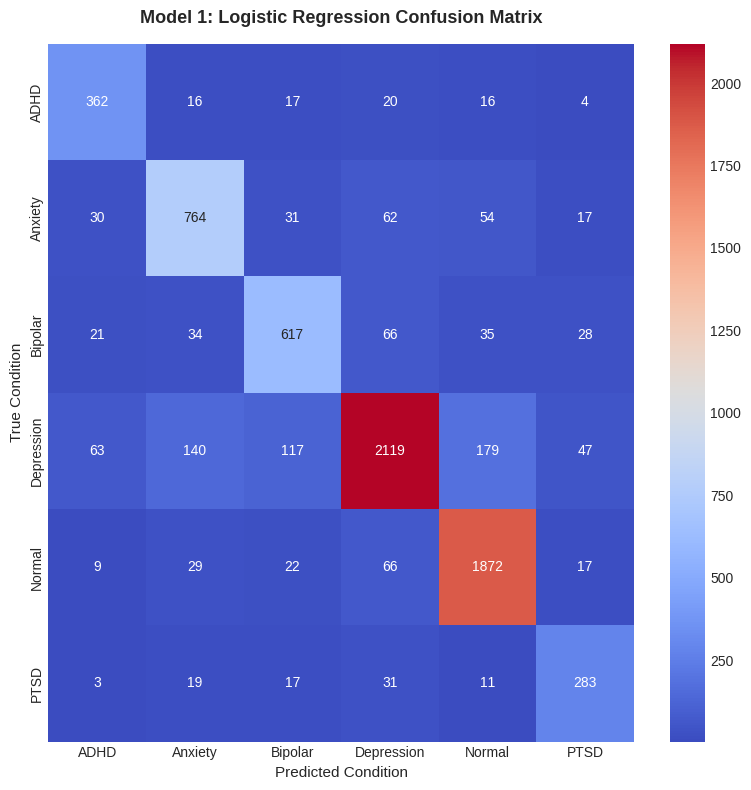

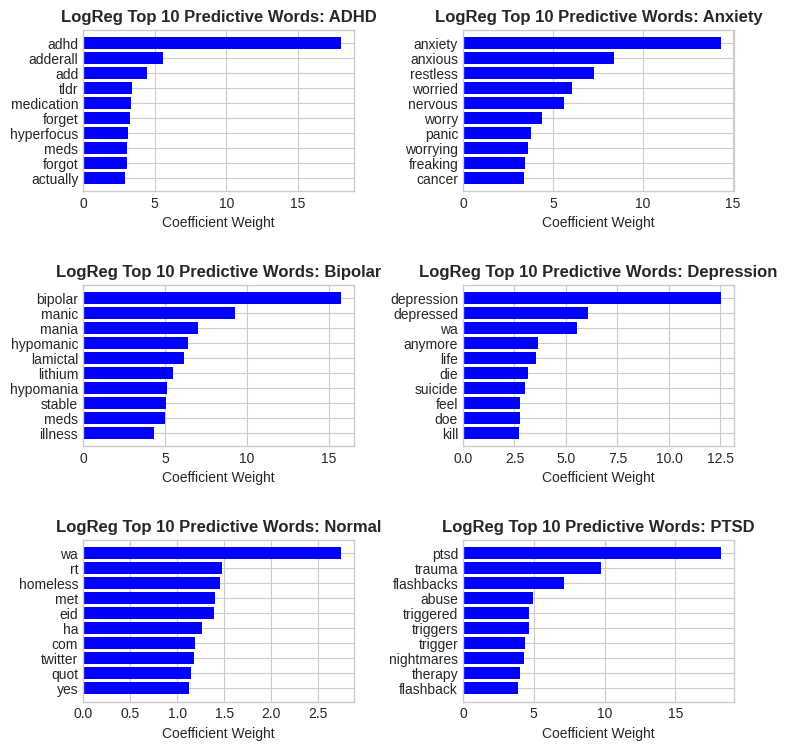

In [21]:

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_tfidf, y_train_idx)

## Predict
y_pred_logreg = logreg.predict(X_val_tfidf)
print("(Validation Set):")
print(classification_report(y_val_idx, y_pred_logreg, target_names=le.classes_))

## record benchmark
macro_f1_scores['Logistic Regression'] = f1_score(y_val_idx, y_pred_logreg, average='macro')
class_f1_scores['Logistic Regression'] = f1_score(y_val_idx, y_pred_logreg, average=None)
print(f"Benchmark to beat -> Macro F1 Score: {macro_f1_scores['Logistic Regression']:.4f}")

## Heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_matrix(y_val_idx, y_pred_logreg), annot=True, fmt='d', cmap='coolwarm',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Model 1: Logistic Regression Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Condition', fontsize=11)
plt.ylabel('True Condition', fontsize=11)
plt.tight_layout()
plt.show()

## Top 10 Highest-Weighted Words per Class
feature_names = tfidf.get_feature_names_out()
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

for i, cls_name in enumerate(le.classes_):
    top10_idx = np.argsort(logreg.coef_[i])[-10:]
    axes[i].barh([feature_names[j] for j in top10_idx], logreg.coef_[i][top10_idx], color='blue')
    axes[i].set_title(f'LogReg Top 10 Predictive Words: {cls_name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Coefficient Weight', fontsize=10)

plt.tight_layout(pad=2.5)
plt.show()

## MODEL I interpertation:
The model performs exceptionally well on the Normal class (F1=0.90) and Depression (F1=0.84). This is partly due to the high "support" the model simply had more data to master these two profiles.
Additionally, Model is showing its ready for catching ADHD and PTSD since they **Recall and Percision** score for these two conmditions is high.
The heatmap highlights that 140 Anxiety posts were misclassified as Depression and 117 Bipolar posts were misclassified as Depression. its good to add that Bipolarity is also classified as depression during clinical research. but the main reason our model is making mistake is because small size of data since its working perfectly for our base and depression.
for Logistic Regression is good to add the exact names of the conditions are the heaviest features.and since perviously we added that many patients use specific words in their posts the model use them as wieghted identifier.


## MODEL II : SVM & SVC

(Validation Set):
              precision    recall  f1-score   support

        ADHD       0.78      0.80      0.79       435
     Anxiety       0.76      0.78      0.77       958
     Bipolar       0.76      0.76      0.76       801
  Depression       0.87      0.82      0.84      2665
      Normal       0.88      0.94      0.90      2015
        PTSD       0.75      0.73      0.74       364

    accuracy                           0.83      7238
   macro avg       0.80      0.80      0.80      7238
weighted avg       0.83      0.83      0.83      7238



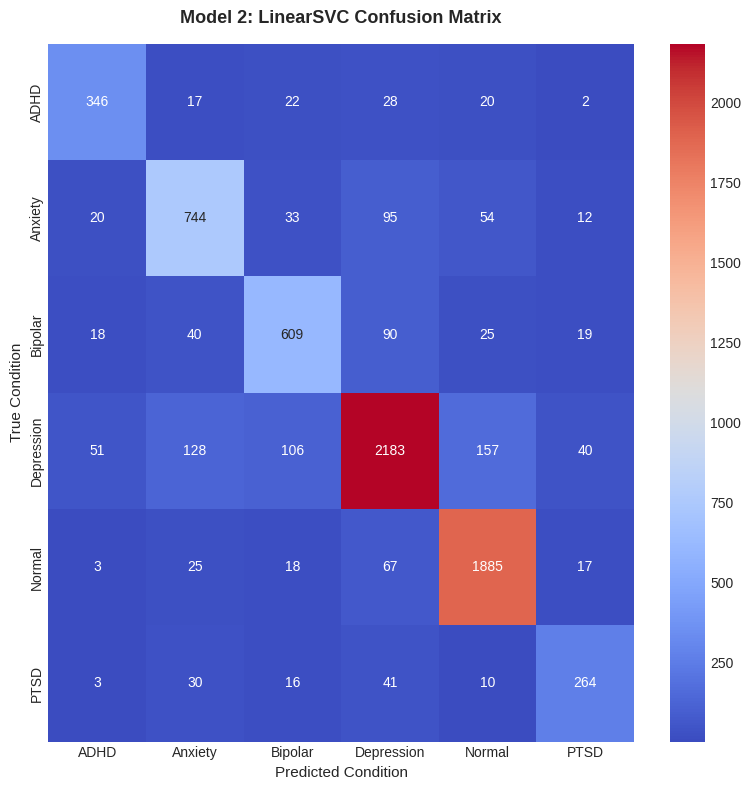

Benchmark Comparison -> LogReg Macro F1: 0.8012 vs. LinearSVC Macro F1: 0.8000


In [22]:
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train_idx)

## Predict
y_pred_svm = svm_model.predict(X_val_tfidf)
print("(Validation Set):")
print(classification_report(y_val_idx, y_pred_svm, target_names=le.classes_))

## record benchmark
macro_f1_scores['LinearSVC'] = f1_score(y_val_idx, y_pred_svm, average='macro')
class_f1_scores['LinearSVC'] = f1_score(y_val_idx, y_pred_svm, average=None)

## Heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(confusion_matrix(y_val_idx, y_pred_svm), annot=True, fmt='d', cmap='coolwarm',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Model 2: LinearSVC Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Condition', fontsize=11)
plt.ylabel('True Condition', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Benchmark Comparison -> LogReg Macro F1: {macro_f1_scores['Logistic Regression']:.4f} vs. LinearSVC Macro F1: {macro_f1_scores['LinearSVC']:.4f}")

## MODEL II Interpertation
the first thing everyone with Data science knowledge or not will notice is that:
**SVC gives quite identical result as Logistic Regression**
Both models achieved an overall accuracy of 83% and a Macro F1-score of 0.80.
However,While the avf between both model is the same there diffrenecs available:
we can see slight changes in ADHD and ANXIETY.
Overall both models predicted same outcome so its safe to say:
The identical performance confirms that changing the algorithm isn't what will push your accuracy higher. The bottleneck isn't the model—it's the data. The models are making the exact same errors because the language of certain posts so naturally blends together, or because explicit keywords are driving all the predictive power.

## MODEL III : RANDOM FOREST

(Validation Set):
              precision    recall  f1-score   support

        ADHD       0.97      0.46      0.62       435
     Anxiety       0.83      0.61      0.70       958
     Bipolar       0.92      0.55      0.69       801
  Depression       0.69      0.91      0.78      2665
      Normal       0.86      0.92      0.89      2015
        PTSD       0.92      0.39      0.55       364

    accuracy                           0.78      7238
   macro avg       0.86      0.64      0.70      7238
weighted avg       0.81      0.78      0.77      7238



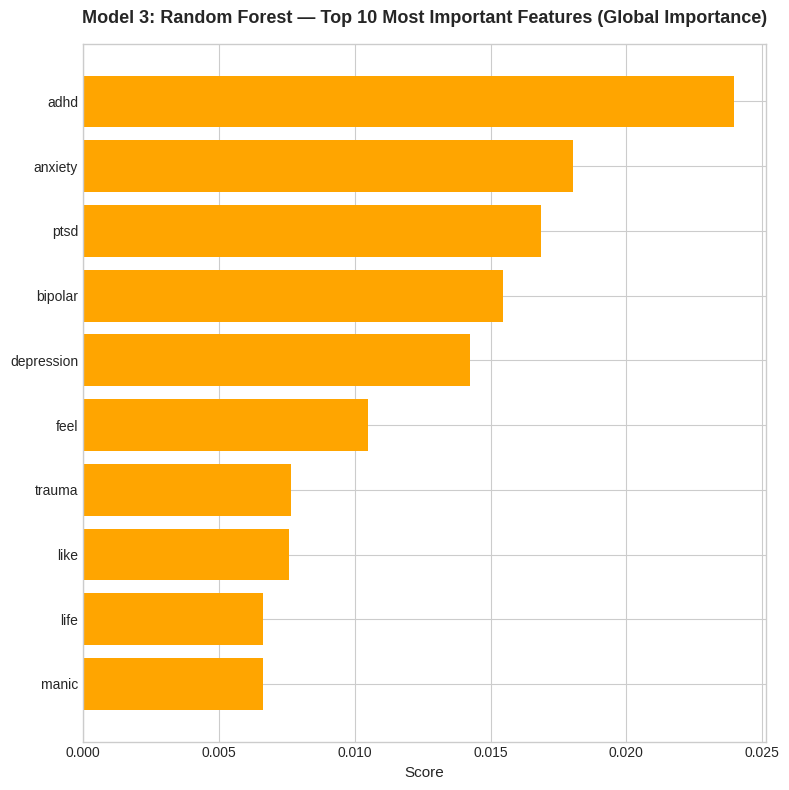

In [23]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train_idx)

## predict
y_pred_rf = rf_model.predict(X_val_tfidf)
print("(Validation Set):")
print(classification_report(y_val_idx, y_pred_rf, target_names=le.classes_))

## record benchmark
macro_f1_scores['Random Forest'] = f1_score(y_val_idx, y_pred_rf, average='macro')
class_f1_scores['Random Forest'] = f1_score(y_val_idx, y_pred_rf, average=None)

## Top 10 Global Feature Importances
importances = rf_model.feature_importances_
top10_global_idx = np.argsort(importances)[-10:]
## plot
plt.figure(figsize=(8, 8))
plt.barh([feature_names[j] for j in top10_global_idx], importances[top10_global_idx], color='Orange')
plt.title('Model 3: Random Forest — Top 10 Most Important Features (Global Importance)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Score', fontsize=11)
plt.tight_layout()
plt.show()

## MODEL III Interpertation:
As we learned in the course the strongest model to train and predict is Random Forest because it can increase its branch and add combine features to assure all teh data will be read and analyzed and its non-linear. first thing in this model we can realize is that Accuracy has dropped by **5%** for this model and F1-macro also by **10** which highlights that **The Precision-Recall Trade-off in Imbalanced Data**
Text data vectorized via TF-IDF creates an incredibly wide, "sparse" matrix. Linear models handle high-dimensional sparse data beautifully. Random Forests, however, pick features at random to make tree splits. When most features are zero for any given post, the trees can get lost in the noise, leading to worse overall performance unless you heavily tune hyperparameters.
- ADHD: Precision jumped to 0.97, but Recall fell to 0.46.
- PTSD: Precision jumped to 0.92, but Recall fell to 0.39.
- Bipolar: Precision jumped to 0.92, but Recall fell to 0.55.
These changes mean : **Forest model has become highly conservative and risk-averse for the smaller classes** Because the decision trees get uncertain in the sparse text space, they default to dumping the ambiguous minority cases into the largest bucket Which in this case is **Deperession**
Therefore, for an online mental health screening tool where missing a case (false negative) is dangerous, the linear baseline models remain superior to the default Random Forest.

MODEL IV:DENSE NEURAL NETWORK

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5397 - loss: 1.2390 - val_accuracy: 0.6688 - val_loss: 0.9485
Epoch 2/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6975 - loss: 0.8633 - val_accuracy: 0.7320 - val_loss: 0.7626
Epoch 3/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7672 - loss: 0.6858 - val_accuracy: 0.7574 - val_loss: 0.7011
Epoch 4/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8181 - loss: 0.5626 - val_accuracy: 0.8045 - val_loss: 0.5733
Epoch 5/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8436 - loss: 0.4889 - val_accuracy: 0.8270 - val_loss: 0.5160
Epoch 6/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8627 - loss: 0.4355 - val_accuracy: 0.8327 - val_loss: 0.5359
Epoch 7/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8759 - loss: 0.3936 - val_accuracy: 0.8490 - val_loss: 0.4680
Epoch 8/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8791 - loss: 0.3780 - val_a

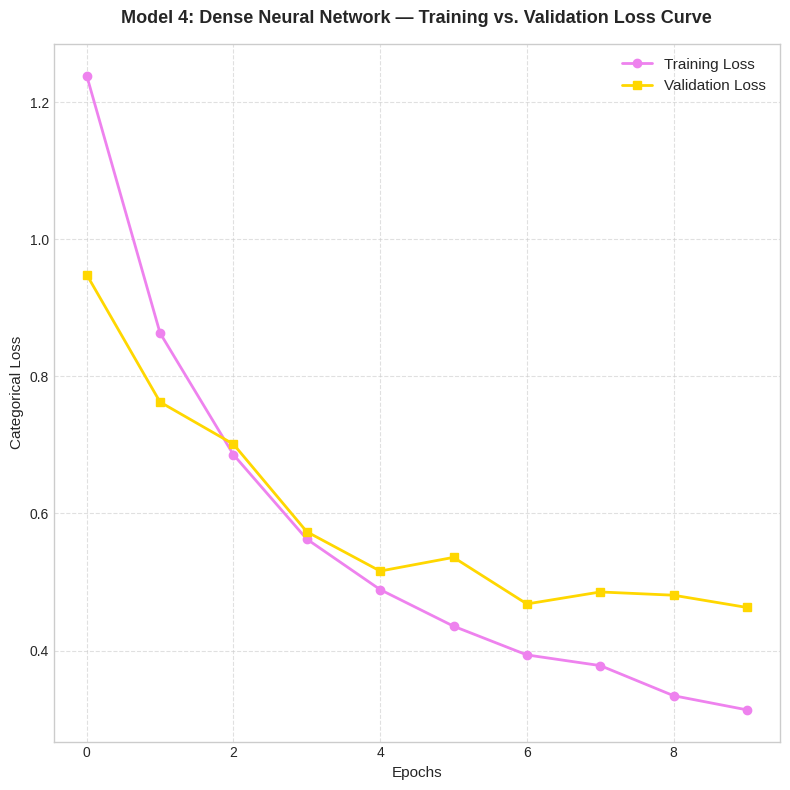

In [24]:

## Build Dense Network Architecture
nn_model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
nn_model.summary()

## Network willl be trained for 10 epochs
history = nn_model.fit(
    X_train_seq, y_train_nn,
    validation_data=(X_val_seq, y_val_nn),
    epochs=10, batch_size=64, verbose=1
)

## Evaluate and predict on validation set
y_pred_nn_probs = nn_model.predict(X_val_seq)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

print("(Validation Set):")
print(classification_report(y_val_idx, y_pred_nn, target_names=le.classes_))

## recored benchmarks
macro_f1_scores['Dense NN'] = f1_score(y_val_idx, y_pred_nn, average='macro')
class_f1_scores['Dense NN'] = f1_score(y_val_idx, y_pred_nn, average=None)

## plot trainning over validation
plt.figure(figsize=(8, 8))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='Violet', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', color='Gold', linewidth=2)
plt.title('Model 4: Dense Neural Network — Training vs. Validation Loss Curve', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Categorical Loss', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##MODEL IV Interperation:
This model shows improvements. overall accuracy jumped from 83% to 86%, and  Macro F1-score climbed from 0.80 to 0.82.
this time Instead of treating words as isolated, independent columns (like TF-IDF), the embedding layer projects words into a continuous, dense vector space. This allows the model to map mathematically similar meanings
The **Global Avg Pooling** layer collapses the sequence dimension by averaging the word embeddings across the entire post. It creates a compact semantic signature for each text slice.
Additonally,The intermediate dense layer learns the complex, non-linear relationships between those word meanings, while the Dropout layer randomly deactivates nodes during training to force the network to stay adaptable and avoid memorizing the dataset.
While the training loss continues its steady descent down to 0.31, the validation loss doesn't curve back upward. This means your Dropout layer did its job perfectly—it prevented the neural network from entering a dangerous overfitting cycle, keeping it perfectly primed for real-world validation data.
Overall our final model has done a better job than other since it used more layers to train and result better for such an importance matter that the youth health is on the line.

## PART VI:MODEL COMPARISon , ETHICS & CONCLUSION

At this phase we start wrapping up .
by Visualizing overall Macro F1 benchmarks and per-class detection capabilities across all four models. Additionally we use our models to analyze the subset we cut from main dataset to see what will the result look like.at first we compare the predictive performance of our four modeling architectures. We evaluate models using Macro F1 scores to ensure minority classes are weighted equally against majority classes.

/tmp/ipykernel_1474/1767817202.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=f1_vals, palette='mako')


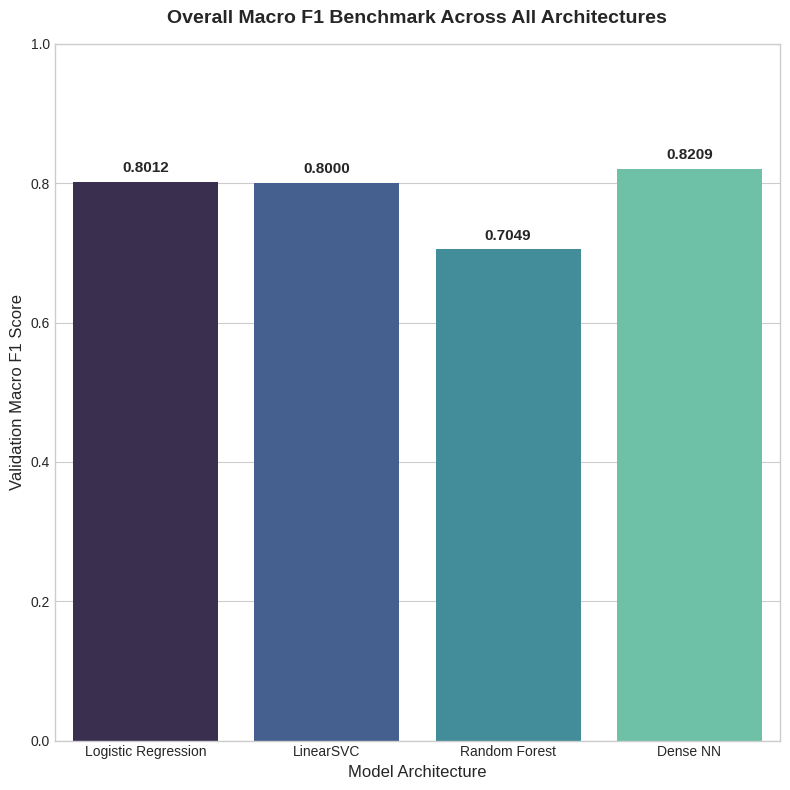

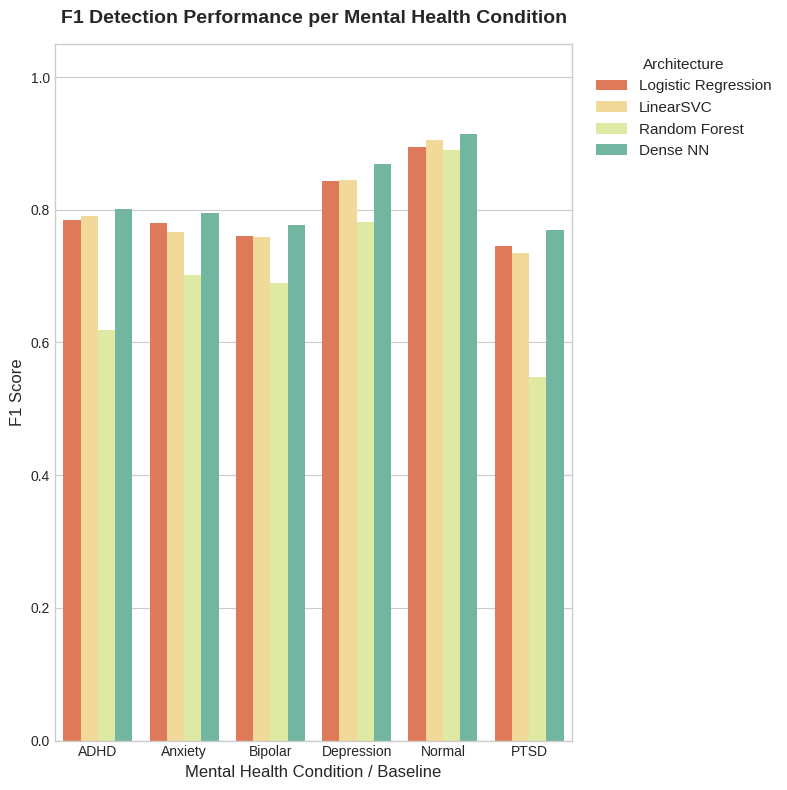

In [25]:
##Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
## MACRO F1 comaprison + Plot
plt.figure(figsize=(8, 8))
model_names = list(macro_f1_scores.keys())
f1_vals = list(macro_f1_scores.values())

ax = sns.barplot(x=model_names, y=f1_vals, palette='mako')
plt.title('Overall Macro F1 Benchmark Across All Architectures', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylabel('Validation Macro F1 Score', fontsize=12)
plt.ylim(0.0, 1.0)
## Adding F1 values at top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## F1 score per class acorss models
df_class_f1 = pd.DataFrame(class_f1_scores, index=le.classes_).reset_index()
df_class_f1 = df_class_f1.melt(id_vars='index', var_name='Model', value_name='F1_Score')
df_class_f1.rename(columns={'index': 'Class'}, inplace=True)

plt.figure(figsize=(8, 8))
sns.barplot(data=df_class_f1, x='Class', y='F1_Score', hue='Model', palette='Spectral')
## Plot
plt.title('F1 Detection Performance per Mental Health Condition', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mental Health Condition / Baseline', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0.0, 1.05)
plt.legend(title='Architecture', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=11)
plt.tight_layout()
plt.show()

## Interpertation:
As we can see both on overall and per class we can identify that:
- **Logistic Regression** (0.8012) and **LinearSVC** (0.8000) bars are virtually identical. This visually proves that standard linear statistical patterns could only extract a maximum of 80% macro-predictive power from your raw text features.
- The **Random Forest** bar drops significantly to 0.7049. This illustrates that picking features at random over a sparse word-count space was highly inefficient for this specific NLP task compared to the other methods.
- **Dense Neural Network** reaches the peak at 0.8219. By mapping the vocabulary into continuous dense embedding spaces, it uncovered non-linear linguistic subtleties, successfully clearing the 80% linear boundary barrier.
overall we can conclude that the best to analyze and uncover health conditions through words and posts is neural network because, this model has the peak overall Macro F1-score of 0.8219, demonstrating superior robustness by consistently outperforming all baseline models across every single individual condition—effectively mitigating class imbalance and providing the most reliable framework for this test.

## Test Model on unlabeled Data

now we use our model on the un labeled data to see what will be the response in comparison to human observation

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
print("--- LOADING HOLDOUT DATA & APPLYING PREPROCESSING ---")
df_holdout = pd.read_csv('mental_health_out_of_scope_holdout.csv')
print(f"Loaded holdout dataset: {len(df_holdout):,} posts.")

## preprocessing pipeline to clean the holdout text
df_holdout['clean_text'] = df_holdout['text'].apply(preprocess_text)
df_holdout = df_holdout[df_holdout['clean_text'].str.strip() != ''].reset_index(drop=True)

## Transform text using Keras Tokenizer
X_holdout_seq = tokenizer.texts_to_sequences(df_holdout['clean_text'])
X_holdout_padded = pad_sequences(X_holdout_seq, maxlen=max_len, padding='post')

## Predict softmax probabilities using Neural network
nn_holdout_probs = nn_model.predict(X_holdout_padded, batch_size=64)

## Extract winning class index and confidence score
nn_holdout_preds = np.argmax(nn_holdout_probs, axis=1)
df_holdout['nn_predicted_class'] = le.inverse_transform(nn_holdout_preds)
df_holdout['nn_confidence_score'] = np.max(nn_holdout_probs, axis=1).round(4)

print("--- STEP 2: EXPORTING PREDICTIONS TO CSV ---")

export_cols = ['text', 'clean_text', 'raw_label', 'holdout_category', 'source', 'word_count', 'nn_predicted_class', 'nn_confidence_score']
export_file = 'mental_health_out_of_scope_nn_predictions.csv'
df_holdout[export_cols].to_csv(export_file, index=False)

## Print
print("Preview of exported Neural Network prediction dataframe:")
print(df_holdout[['raw_label', 'nn_predicted_class', 'nn_confidence_score', 'clean_text']].head().to_string())

## Calculate percentage breakdown of NN predictions for each raw human category
breakdown_table = pd.crosstab(
    df_holdout['raw_label'],
    df_holdout['nn_predicted_class'],
    normalize='index'
) * 100

breakdown_table = breakdown_table.round(1)
print(breakdown_table.to_string())

--- LOADING HOLDOUT DATA & APPLYING PREPROCESSING ---
Loaded holdout dataset: 16,036 posts.
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- STEP 2: EXPORTING PREDICTIONS TO CSV ---
Preview of exported Neural Network prediction dataframe:
  raw_label nn_predicted_class  nn_confidence_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Final Note
- When our Dense Neural Network evaluated 10,503 Suicidal posts, it classified an overwhelming 88.2% of them as Depression with an exceptionally high average softmax confidence of 93.3%.The driver of this decsion is the neural network embedding layer learned that words like hopeless, pain, sleep, end, tired, and heavy first-person pronouns are the primary geometric vectors for clinical Depression. Because Suicidal crisis language shares this exact vocabulary of despair, the neural network cannot distinguish between chronic depressive rumination and acute suicidal ideation So it will classify them as depression. Its also good that Depression is one of the triggers for people to think about sucidal thoughts which can say the prediction was correct.

 - a qualitative inspection of the exported CSV explains the ADHD spike among uunlabeled users. general Reddit posts frequently involve long, structured lists, hyperfixation sharing (such as travel destination guides or gaming setups), and informal, stream-of-consciousness formatting. Furthermore, casual internet slang relies heavily on emotional hyperbole. Because dense neural embeddings process structural verbosity and jumping topics as markers of executive dysfunction, model predicted internet hyperbole everyday online humor as ADHD or mood disorders.
- When evaluating non-clinical Stress (2,285 posts), the neural network fractured its predictions across Anxiety (36.1%), Depression (25.6%), and Normal (18.7%), with a lower average confidence score of 70.3%.
Everyday stress exists on a linguistic bridge between healthy baseline worry and clinical anxiety disorder. When individuals write about workplace burnout, financial strain, or upcoming exams, they utilize distress keywords that trigger the neural network's Anxiety neurons. This proves that without longitudinal medical history and clinical context, NLP screening tools risk over-medicalizing normal human responses to stressful life events.
The Edge-Case Boundary (Personality disorder)
  
- Additonally on complex conditions like Borderline or Narcissistic Personality Disorder (889 posts), predictions split heavily between Depression (38.6%) and Anxiety (28.4%), with the lowest overall model confidence (69.7%).  
 Personality disorders are characterized by interpersonal volatility, splitting, and severe emotional swings. When forced through a 6-class neural network, the embedding layer maps the depressive lows to Depression and the relational panic to Anxiety. The low confidence score (averaging ~69.7% compared to 91% for suicidal posts) proves that the neural network's softmax distribution is "aware" of its own diagnostic uncertainty when confronted with out-of-scope psychological pathology.

 - Finally, our research shows that identifying psychological issue is very extensive and needed human expert attention and its not something to fully be rellied on machine as Illinois is one of the first state to ban psychological ai apps to use its good step to show that we cannot fully rely on machines for such important task that youth health is on the line. while these prediuction could help experts learn more about their patients they still highlight importance of real experts in mental health.